# Canonical NBA Play-by-Play Dataset

**Goal:** Build a unified play-by-play dataset for backtesting sports betting algorithms.

## Data source

All NBA data comes from `cdn.nba.com` REST endpoints (no auth required):

| Dataset | S3 key pattern | Description |
|---------|---------------|-------------|
| Schedule | `nba_cdn/schedule/season_{year}.json` | Full season schedule with game IDs, dates, teams |
| Play-by-play | `nba_cdn/play_by_play/{game_id}.json` | Per-action PBP with `timeActual` (wall-clock timestamps) |
| Box scores | `nba_cdn/boxscore/{game_id}.json` | Per-player and team stats |
| Live PBP | `bronze/nba_cdn/live_pbp/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | Real-time PBP captured by live ingester |

The CDN PBP endpoint provides 56 fields per action including `timeActual` (ISO 8601 wall-clock timestamp), which is essential for joining game state to Kalshi market timestamps.

## Approach

1. Explore game-level data (season schedule, completed games)
2. Explore PBP schema and sample data
3. Load Kalshi market data and examine the join strategy

In [72]:
import json
import boto3
import pandas as pd

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # auto-detect width
pd.set_option("display.max_colwidth", None)  # full cell content

S3_BUCKET = "prediction-markets-data"
s3 = boto3.client("s3")

## 1. Game-level exploration

Load the season schedule from S3 to understand coverage and pick sample games for PBP exploration.

In [73]:
# List what's in the nba_cdn/ prefix
resp = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix="nba_cdn/", Delimiter="/")
for prefix in resp.get("CommonPrefixes", []):
    print(prefix["Prefix"])

nba_cdn/boxscore/
nba_cdn/play_by_play/
nba_cdn/schedule/


In [74]:
# Load season schedule from S3
SEASON = "2025-26"

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/schedule/season_{SEASON}.json")
schedule_raw = json.loads(obj["Body"].read())

# Flatten schedule into a games dataframe
games = []
for game_date in schedule_raw["leagueSchedule"]["gameDates"]:
    for g in game_date["games"]:
        games.append({
            "game_id": g["gameId"],
            "game_date": g["gameDateEst"],
            "game_status": g["gameStatus"],  # 1=scheduled, 2=in-progress, 3=final
            "home_team": g["homeTeam"]["teamTricode"],
            "away_team": g["awayTeam"]["teamTricode"],
            "game_label": g.get("gameLabel", ""),
        })

df = pd.DataFrame(games)

# Derive game type from game_id prefix (3rd digit)
game_type_map = {"1": "Preseason", "2": "Regular Season", "3": "All-Star", "4": "Playoffs"}
df["game_type"] = df["game_id"].astype(str).str[2].map(game_type_map)

completed = df[df["game_status"] == 3]
print(f"{len(df)} total games, {len(completed)} completed")
print(f"\nBy type:")
print(df["game_type"].value_counts())
df.head()

1378 total games, 1321 completed

By type:
game_type
Regular Season    1230
Preseason           71
Playoffs            63
All-Star             7
Name: count, dtype: int64


,game_id,game_date,game_status,home_team,away_team,game_label,game_type
0,0012500008,2025-10-02T00:00:00Z,3,NYK,PHI,Preseason,Preseason
1,0012500001,2025-10-03T00:00:00Z,3,LAL,PHX,Preseason,Preseason
2,0012500009,2025-10-03T00:00:00Z,3,NOP,MEL,Preseason,Preseason
3,0012500010,2025-10-04T00:00:00Z,3,PHI,NYK,Preseason,Preseason
4,0012500011,2025-10-04T00:00:00Z,3,NOP,SEM,Preseason,Preseason


In [75]:
df["game_type"].value_counts()

game_type
Regular Season    1230
Preseason           71
Playoffs            63
All-Star             7
Name: count, dtype: int64

In [76]:
df.shape

(1378, 7)

In [77]:
df.describe()

,game_status
count,1378.000000
mean,2.917997
std,0.395815
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,3.000000


## 2. Play-by-play exploration

### CDN PBP

Source: `cdn.nba.com/static/json/liveData/playbyplay/playbyplay_{game_id}.json`
- S3 path: `s3://prediction-markets-data/nba_cdn/play_by_play/{game_id}.json`
- Coverage: all completed games backfilled via `fetch_play_by_play --season`
- 56 fields per action including `timeActual` (wall-clock ISO timestamp)

In [78]:
# Pick a completed regular season game
sample_game = completed[completed["game_type"] == "Regular Season"].iloc[0]
sample_game_id = sample_game["game_id"]
print(f"Game: {sample_game_id} ({sample_game['away_team']} @ {sample_game['home_team']}, {sample_game['game_date']})")

# Load PBP from S3
obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{sample_game_id}.json")
pbp_raw = json.loads(obj["Body"].read())
actions = pbp_raw.get("game", {}).get("actions", [])
pbp_df = pd.DataFrame(actions)
print(f"{len(pbp_df)} actions, {pbp_df.shape[1]} columns")
print(f"\nColumns: {pbp_df.columns.tolist()}")
pbp_df.head(10)

Game: 0022500001 (HOU @ OKC, 2025-10-21T00:00:00Z)
707 actions, 56 columns

Columns: ['actionNumber', 'clock', 'timeActual', 'period', 'periodType', 'actionType', 'subType', 'qualifiers', 'personId', 'x', 'y', 'possession', 'scoreHome', 'scoreAway', 'edited', 'orderNumber', 'isTargetScoreLastPeriod', 'xLegacy', 'yLegacy', 'isFieldGoal', 'side', 'description', 'personIdsFilter', 'teamId', 'teamTricode', 'descriptor', 'jumpBallRecoveredName', 'jumpBallRecoverdPersonId', 'playerName', 'playerNameI', 'jumpBallWonPlayerName', 'jumpBallWonPersonId', 'jumpBallLostPlayerName', 'jumpBallLostPersonId', 'area', 'areaDetail', 'shotDistance', 'shotResult', 'shotActionNumber', 'reboundTotal', 'reboundDefensiveTotal', 'reboundOffensiveTotal', 'pointsTotal', 'assistPlayerNameInitial', 'assistPersonId', 'assistTotal', 'officialId', 'foulPersonalTotal', 'foulTechnicalTotal', 'foulDrawnPlayerName', 'foulDrawnPersonId', 'turnoverTotal', 'stealPlayerName', 'stealPersonId', 'blockPlayerName', 'blockPersonId

,actionNumber,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,y,possession,scoreHome,scoreAway,edited,orderNumber,isTargetScoreLastPeriod,xLegacy,yLegacy,isFieldGoal,side,description,personIdsFilter,teamId,teamTricode,descriptor,jumpBallRecoveredName,jumpBallRecoverdPersonId,playerName,playerNameI,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,area,areaDetail,shotDistance,shotResult,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,officialId,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,turnoverTotal,stealPlayerName,stealPersonId,blockPlayerName,blockPersonId
0,2,PT12M00.00S,2025-10-21T23:43:24.7Z,1,REGULAR,period,start,[],0,NaN,NaN,0,0,0,2025-10-21T23:43:24Z,20000,False,NaN,NaN,0,NaN,Period Start,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4,PT11M56.00S,2025-10-21T23:43:27.2Z,1,REGULAR,jumpball,recovered,[],1641708,NaN,NaN,1610612745,0,0,2025-10-21T23:43:27Z,40000,False,NaN,NaN,0,NaN,Jump Ball S. Adams vs. C. Holmgren: Tip to A. Thompson,"[1641708, 203500, 1631096]",1.610613e+09,HOU,startperiod,A. Thompson,1641708.0,Thompson,A. Thompson,Adams,203500.0,Holmgren,1631096.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8,PT11M36.00S,2025-10-21T23:43:59.9Z,1,REGULAR,3pt,Jump Shot,[],1630578,24.655059,85.784314,1610612745,0,0,2025-10-21T23:44:05Z,80000,False,-179.0,179.0,1,left,MISS A. Sengun 25' 3PT,[1630578],1.610613e+09,HOU,NaN,NaN,NaN,Sengun,A. Sengun,NaN,NaN,NaN,NaN,Above the Break 3,24+ Left Center,25.33,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,PT11M31.00S,2025-10-21T23:44:04.9Z,1,REGULAR,rebound,defensive,[],1641717,NaN,NaN,1610612760,0,0,2025-10-21T23:44:05Z,90000,False,NaN,NaN,0,NaN,C. Wallace REBOUND (Off:0 Def:1),[1641717],1.610613e+09,OKC,NaN,NaN,NaN,Wallace,C. Wallace,NaN,NaN,NaN,NaN,Above the Break 3,24+ Left Center,NaN,NaN,8.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10,PT11M26.00S,2025-10-21T23:44:12.5Z,1,REGULAR,2pt,Layup,[pointsinthepaint],1631096,92.986202,50.000000,1610612760,2,0,2025-10-21T23:44:19Z,100000,False,0.0,13.0,1,right,C. Holmgren cutting Layup (2 PTS) (L. Dort 1 AST),"[1631096, 1629652]",1.610613e+09,OKC,cutting,NaN,NaN,Holmgren,C. Holmgren,NaN,NaN,NaN,NaN,Restricted Area,0-8 Center,1.34,Made,NaN,NaN,NaN,NaN,2.0,L. Dort,1629652.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,12,PT11M26.00S,2025-10-21T23:44:14.3Z,1,REGULAR,foul,personal,[1freethrow],1631095,NaN,NaN,1610612760,2,0,2025-10-21T23:44:24Z,120000,False,NaN,NaN,0,NaN,J. Smith Jr. shooting personal FOUL (1 PF) (Holmgren 1 FT),"[1631095, 1631096]",1.610613e+09,HOU,shooting,NaN,NaN,Smith Jr.,J. Smith Jr.,NaN,NaN,NaN,NaN,Restricted Area,0-8 Center,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200833.0,1.0,0.0,Holmgren,1631096.0,NaN,NaN,NaN,NaN,NaN
6,14,PT11M26.00S,2025-10-21T23:44:48.5Z,1,REGULAR,freethrow,1 of 1,[],1631096,NaN,NaN,1610612760,3,0,2025-10-21T23:44:48Z,140000,False,NaN,NaN,0,NaN,C. Holmgren Free Throw 1 of 1 (3 PTS),[1631096],1.610613e+09,OKC,NaN,NaN,NaN,Holmgren,C. Holmgren,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Made,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,15,PT11M08.00S,2025-10-21T23:45:08.6Z,1,REGULAR,3pt,Jump Shot,[],1641708,5.601183,3.431373,1610612745,3,0,2025-10-21T23:45:14Z,150000,False,233.0,0.0,1,left,MISS A. Thompson 3PT,[1641708],1.610613e+09,HOU,NaN,NaN,NaN,Thompson,A. Thompson,NaN,NaN,NaN,NaN,Right Corner 3,24+ Right,23.28,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,16,PT11M04.00S,2025-10-21T23:45:12.6Z,1,REGULAR,rebound,offensive,[],1631095,NaN,NaN,1610612745,3,0,2025-10-21T23:45:14Z,160000,False,NaN,NaN,0,NaN,J. Smith Jr. REBOUND (Off:1 Def:0),[1631095],1.610613e+09,HOU,NaN,NaN

### Receipt latency — NBA CDN

`timeActual` is when the play happened on court. `t_receipt` is when our poller received it.
The difference tells us how stale PBP data is in production — important for backtesting
so we don't act on game state we wouldn't have seen yet.

Actions with lag >60s are excluded (first-poll catch-up on already-happened actions).

In [80]:
import gzip

# Load bronze live PBP to measure t_receipt - timeActual
resp = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix="bronze/nba_cdn/live_pbp/")
nba_bronze_keys = [o["Key"] for o in resp.get("Contents", [])]

nba_records = []
for key in nba_bronze_keys[:200]:
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    raw = gzip.decompress(obj["Body"].read())
    for line in raw.decode().strip().split("\n"):
        r = json.loads(line)
        nba_records.append({
            "timeActual": r["frame"].get("timeActual"),
            "t_receipt": r.get("t_receipt"),
        })

nba_lag_df = pd.DataFrame(nba_records)
nba_lag_df["ta"] = pd.to_datetime(nba_lag_df["timeActual"], utc=True)
nba_lag_df["tr"] = pd.to_datetime(nba_lag_df["t_receipt"], unit="s", utc=True)
nba_lag_df["lag"] = (nba_lag_df["tr"] - nba_lag_df["ta"]).dt.total_seconds()

# Exclude first-poll catch-up actions
nba_lag_steady = nba_lag_df[nba_lag_df["lag"] <= 60]["lag"]
print(f"{len(nba_lag_df)} total actions, {len(nba_lag_steady)} steady-state (lag <= 60s)")
print(f"Median: {nba_lag_steady.median():.1f}s, p95: {nba_lag_steady.quantile(0.95):.1f}s")
nba_lag_df.head()

1432 total actions, 1031 steady-state (lag <= 60s)
Median: 12.0s, p95: 38.5s


,timeActual,t_receipt,ta,tr,lag
0,2026-04-18T22:54:14.2Z,1.776553e+09,2026-04-18 22:54:14.200000+00:00,2026-04-18 22:54:20.960214853+00:00,6.760215
1,2026-04-18T22:54:35.5Z,1.776553e+09,2026-04-18 22:54:35.500000+00:00,2026-04-18 22:54:48.722672701+00:00,13.222673
2,2026-04-18T22:54:36.5Z,1.776553e+09,2026-04-18 22:54:36.500000+00:00,2026-04-18 22:54:48.722672701+00:00,12.222673
3,2026-04-18T22:37:56.8Z,1.776552e+09,2026-04-18 22:37:56.800000+00:00,2026-04-18 22:38:10.655314445+00:00,13.855314
4,2026-04-18T22:37:59.8Z,1.776552e+09,2026-04-18 22:37:59.800000+00:00,2026-04-18 22:38:10.655314445+00:00,10.855314


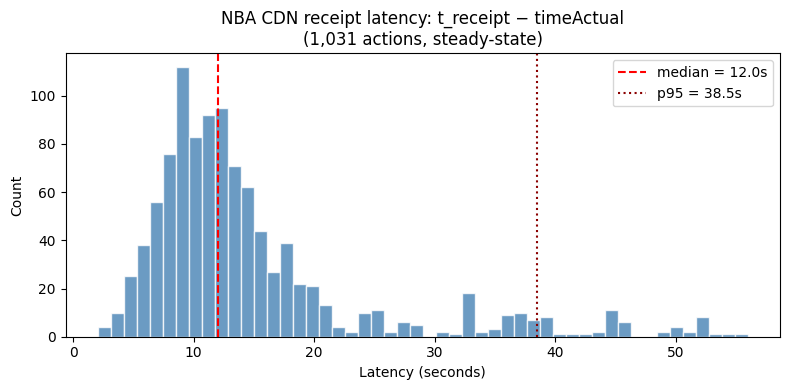

In [82]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nba_lag_steady, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(nba_lag_steady.median(), color="red", linestyle="--",
           label=f"median = {nba_lag_steady.median():.1f}s")
ax.axvline(nba_lag_steady.quantile(0.95), color="darkred", linestyle=":",
           label=f"p95 = {nba_lag_steady.quantile(0.95):.1f}s")
ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Count")
ax.set_title(f"NBA CDN receipt latency: t_receipt − timeActual\n({len(nba_lag_steady):,} actions, steady-state)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Kalshi market data — can we join on game state?

To backtest betting strategies, we need to correlate NBA game state (score, period, clock) with Kalshi market prices. The question is: does Kalshi data contain game state fields we can join on, or do we need to join on wall-clock time?

**Kalshi data in S3:**

| Dataset | S3 key pattern | Key fields |
|---------|---------------|------------|
| Historical markets | `kalshi/historical_markets/{series}.json` | `ticker`, `event_ticker`, `title`, `open_time`, `close_time`, `result` |
| Historical trades | `kalshi/historical_trades/{ticker}.json` | `ticker`, `price`, `count`, `taker_side`, `created_time` |
| Historical candlesticks | `kalshi/historical_candlesticks/{interval}m/{ticker}.json` | OHLC + `volume` + `timestamp` |
| Live orderbook snapshots | `bronze/kalshi_ws/orderbook_snapshot/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | `market_ticker`, `bids`, `asks` |
| Live orderbook deltas | `bronze/kalshi_ws/orderbook_delta/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | `market_ticker`, price/size deltas |
| Live trades | `bronze/kalshi_ws/trade/YYYY/MM/DD/HH/{uuid}.jsonl.gz` | `market_ticker`, `price`, `count`, `taker_side`, `created_time` |

In [47]:
# Load a sample historical markets file (e.g. KXNBAGAME — win/loss)
obj = s3.get_object(Bucket=S3_BUCKET, Key="kalshi/historical_markets/KXNBAGAME.json")
markets_raw = json.loads(obj["Body"].read())
markets_df = pd.DataFrame(markets_raw)
print(f"{len(markets_df)} markets")
print(f"\nColumns: {markets_df.columns.tolist()}")
markets_df.head(2)

1902 markets

Columns: ['can_close_early', 'close_time', 'created_time', 'custom_strike', 'early_close_condition', 'event_ticker', 'expected_expiration_time', 'expiration_time', 'expiration_value', 'fractional_trading_enabled', 'last_price_dollars', 'latest_expiration_time', 'liquidity_dollars', 'market_type', 'no_ask_dollars', 'no_bid_dollars', 'no_sub_title', 'notional_value_dollars', 'open_interest_fp', 'open_time', 'previous_price_dollars', 'previous_yes_ask_dollars', 'previous_yes_bid_dollars', 'price_level_structure', 'price_ranges', 'response_price_units', 'result', 'rules_primary', 'rules_secondary', 'settlement_timer_seconds', 'settlement_ts', 'settlement_value_dollars', 'status', 'strike_type', 'tick_size', 'ticker', 'title', 'updated_time', 'volume_24h_fp', 'volume_fp', 'yes_ask_dollars', 'yes_ask_size_fp', 'yes_bid_dollars', 'yes_bid_size_fp', 'yes_sub_title']


,can_close_early,close_time,created_time,custom_strike,early_close_condition,event_ticker,expected_expiration_time,expiration_time,expiration_value,fractional_trading_enabled,last_price_dollars,latest_expiration_time,liquidity_dollars,market_type,no_ask_dollars,no_bid_dollars,no_sub_title,notional_value_dollars,open_interest_fp,open_time,previous_price_dollars,previous_yes_ask_dollars,previous_yes_bid_dollars,price_level_structure,price_ranges,response_price_units,result,rules_primary,rules_secondary,settlement_timer_seconds,settlement_ts,settlement_value_dollars,status,strike_type,tick_size,ticker,title,updated_time,volume_24h_fp,volume_fp,yes_ask_dollars,yes_ask_size_fp,yes_bid_dollars,yes_bid_size_fp,yes_sub_title
0,True,2026-02-13T05:37:28Z,2026-02-10T17:02:09.225173Z,{'basketball_team': '2ef4d31c-0b46-4f43-a403-f44d62489034'},This market will close and expire after a winner is declared.,KXNBAGAME-26FEB12DALLAL,2026-02-13T06:00:00Z,2026-02-27T03:00:00Z,Los Angeles L,False,0.9900,2026-02-27T03:00:00Z,0.0000,binary,1.0000,0.0000,Los Angeles L,1.0000,0.00,2026-02-10T22:06:00Z,0.9900,1.0000,0.0000,linear_cent,"[{'end': '1.0000', 'start': '0.0000', 'step': '0.0100'}]",usd_cent,yes,"If Los Angeles L wins the Dallas at Los Angeles L professional basketball game originally scheduled for Feb 12, 2026, then the market resolves to Yes.",,30,2026-02-13T05:39:01.690752Z,1.0000,finalized,structured,1,KXNBAGAME-26FEB12DALLAL-LAL,Dallas at Los Angeles L Winner?,2026-02-19T08:48:16.628714Z,0.00,4954411.00,1.0000,0.00,0.0000,0.00,Los Angeles L
1,True,2026-02-13T05:37:28Z,2026-02-10T17:02:09.225173Z,{'basketball_team': '36547ae6-f0fa-4d06-a6e5-5bfa64a217ed'},This market will close and expire after a winner is declared.,KXNBAGAME-26FEB12DALLAL,2026-02-13T06:00:00Z,2026-02-27T03:00:00Z,Los Angeles L,False,0.0100,2026-02-27T03:00:00Z,0.0000,binary,1.0000,0.0000,Dallas,1.0000,0.00,2026-02-10T22:06:00Z,0.0100,1.0000,0.0000,linear_cent,"[{'end': '1.0000', 'start': '0.0000', 'step': '0.0100'}]",usd_cent,no,"If Dallas wins the Dallas at Los Angeles L professional basketball game originally scheduled for Feb 12, 2026, then the market resolves to Yes.",,30,2026-02-13T05:39:01.690752Z,0.0000,finalized,structured,1,KXNBAGAME-26FEB12DALLAL-DAL,Dallas at Los Angeles L Winner?,2026-02-19T08:48:16.628714Z,0.00,3744380.00,1.0000,0.00,0.0000,0.00,Dallas


In [66]:
# Load trades for one ticker to see the schema
sample_ticker = markets_df["ticker"].iloc[0]
print(f"Sample ticker: {sample_ticker}")

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{sample_ticker}.json")
trades_raw = json.loads(obj["Body"].read())
trades_df = pd.DataFrame(trades_raw)
print(f"{len(trades_df)} trades")
print(f"Columns: {trades_df.columns.tolist()}")
trades_df.head()

Sample ticker: KXNBAGAME-26FEB12DALLAL-LAL
22533 trades
Columns: ['count_fp', 'created_time', 'no_price_dollars', 'taker_side', 'ticker', 'trade_id', 'yes_price_dollars']


,count_fp,created_time,no_price_dollars,taker_side,ticker,trade_id,yes_price_dollars
0,15.00,2026-02-13T05:30:39.335643Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,3f8fa67d-6fbf-40e0-5f40-6fe027f593a3,0.9900
1,52.00,2026-02-13T05:30:37.195315Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,973b978b-87bf-4a28-fd3c-1acc939fdd77,0.9900
2,20.00,2026-02-13T05:30:34.13469Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,39ffa7cd-b71f-5b80-1dfa-529b3df1485b,0.9900
3,6.00,2026-02-13T05:30:33.604435Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,c6333019-83a7-561c-eba4-748526b6b773,0.9900
4,19.00,2026-02-13T05:30:32.710968Z,0.0100,no,KXNBAGAME-26FEB12DALLAL-LAL,7074d157-0383-4bc8-2f9c-38e05e56698f,0.9900


In [71]:
# Load live Kalshi WS trades from bronze
resp = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix="bronze/kalshi_ws/trade/")
kalshi_bronze_keys = [obj["Key"] for obj in resp.get("Contents", [])]
print(f"{len(kalshi_bronze_keys)} bronze kalshi_ws/trade files in S3")

if kalshi_bronze_keys:
    all_ws_trades = []
    for key in kalshi_bronze_keys[:20]:
        obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
        raw_bytes = gzip.decompress(obj["Body"].read())
        for line in raw_bytes.decode().strip().split("\n"):
            record = json.loads(line)
            frame = record["frame"]
            # WS trade frames have msg nested inside
            msg = frame.get("msg", {})
            msg["t_receipt"] = record.get("t_receipt")
            all_ws_trades.append(msg)
    ws_trades_df = pd.DataFrame(all_ws_trades)
    print(f"Read {len(kalshi_bronze_keys[:20])} files, {len(ws_trades_df)} trades")
    print(f"\nColumns: {ws_trades_df.columns.tolist()}")
    ws_trades_df.head(10)
else:
    print("No bronze kalshi_ws/trade data yet — run: python -m scripts.live.kalshi_ws")

ws_trades_df['latency'] = ws_trades_df['t_receipt'] - ws_trades_df['ts']
ws_trades_df.head()

1000 bronze kalshi_ws/trade files in S3
Read 20 files, 20723 trades

Columns: ['trade_id', 'market_ticker', 'yes_price_dollars', 'no_price_dollars', 'count_fp', 'taker_side', 'ts', 't_receipt']


,trade_id,market_ticker,yes_price_dollars,no_price_dollars,count_fp,taker_side,ts,t_receipt,latency
0,7a22e120-d6f4-4e74-455f-66ce14a4a774,KXNBASPREAD-26APR18HOULAL-LAL7,0.3300,0.6700,35.00,yes,1776560193,1.776560e+09,0.978654
1,ce1bd8a6-6665-4f2a-4067-c9d85c241740,KXNBASPREAD-26APR18HOULAL-LAL7,0.3300,0.6700,22.00,yes,1776560193,1.776560e+09,0.978673
2,03fbfd64-cc40-4a05-b818-a0f4887f3e0e,KXNBATOTAL-26APR18HOULAL-198,0.8600,0.1400,12.00,yes,1776560193,1.776560e+09,0.985253
3,4a0a2ea7-5cda-477f-8aec-ba83af8d608a,KXNBATOTAL-26APR18HOULAL-198,0.8600,0.1400,54.37,yes,1776560193,1.776560e+09,0.985382
4,07f1f331-d4d8-741c-30a1-0d1d0aeb847a,KXNBAGAME-26APR18HOULAL-HOU,0.4800,0.5200,100.00,yes,1776560194,1.776560e+09,0.148268


### Receipt latency — Kalshi WS

`ts` is the exchange timestamp (when the trade executed). `t_receipt` is when our
WebSocket client received the message. Sub-second latency is expected for a direct WS connection.

In [83]:
kalshi_lag = ws_trades_df["t_receipt"] - ws_trades_df["ts"]
print(f"{len(kalshi_lag):,} trades, median lag {kalshi_lag.median():.3f}s, p95 {kalshi_lag.quantile(0.95):.3f}s")

20,723 trades, median lag 0.526s, p95 0.985s


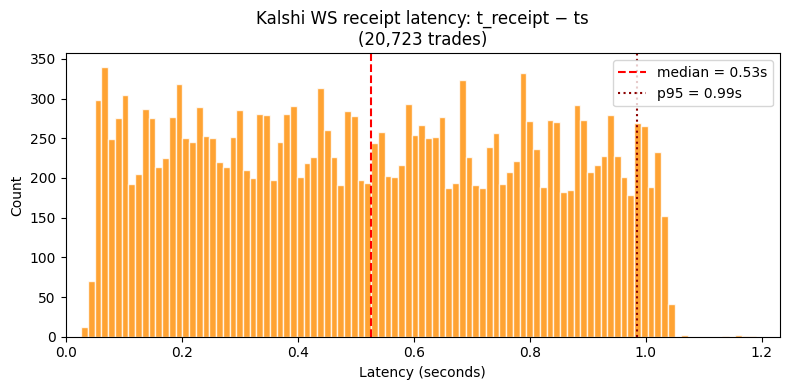

In [84]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(kalshi_lag, bins=100, color="darkorange", edgecolor="white", alpha=0.8)
ax.axvline(kalshi_lag.median(), color="red", linestyle="--",
           label=f"median = {kalshi_lag.median():.2f}s")
ax.axvline(kalshi_lag.quantile(0.95), color="darkred", linestyle=":",
           label=f"p95 = {kalshi_lag.quantile(0.95):.2f}s")
ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Count")
ax.set_title(f"Kalshi WS receipt latency: t_receipt − ts\n({len(kalshi_lag):,} trades)")
ax.legend()
ax.set_xlim(0, kalshi_lag.quantile(0.99) * 1.2)
plt.tight_layout()
plt.show()

### 3a. Joining Kalshi to NBA — observations

Kalshi data has **no game state fields** (`period`, `clock`, `score`). It is purely market data. The only way to correlate market prices with game state is:

1. **Map ticker to game**: parse `event_ticker` (e.g. `KXNBAGAME-25APR18-LALBOS-YES`) to extract date + teams, then match to an NBA `game_id`
2. **Join on wall-clock time**: Kalshi trades have `created_time`, NBA CDN PBP has `timeActual` — align by timestamp to answer "what was the market price when this play happened?"

### 3b. Mapping Kalshi event_ticker → NBA game_id

The `event_ticker` encodes the game: `KXNBAGAME-{YY}{MON}{DD}{AWAY}{HOME}`

For example: `KXNBAGAME-25DEC25MINDEN` → Dec 25, 2025, MIN @ DEN

We can parse this and match against the CDN schedule to get the `game_id`.

In [67]:
import re

MONTH_MAP = {
    "JAN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAY": "05", "JUN": "06", "JUL": "07", "AUG": "08",
    "SEP": "09", "OCT": "10", "NOV": "11", "DEC": "12",
}

# Build schedule lookup: (date, away, home) -> game_id
schedule_lookup = {}
for game_date in schedule_raw["leagueSchedule"]["gameDates"]:
    for g in game_date["games"]:
        date_str = g["gameDateEst"][:10]
        away = g["awayTeam"].get("teamTricode", "")
        home = g["homeTeam"].get("teamTricode", "")
        if away and home:
            schedule_lookup[(date_str, away, home)] = g["gameId"]

def parse_event_ticker(event_ticker: str):
    """Parse KXNBAGAME-{YY}{MON}{DD}{AWAY}{HOME} into (date, away, home, game_id)."""
    m = re.match(r"KXNBAGAME-(\d{2})([A-Z]{3})(\d{2})(.{3})(.{3})", event_ticker)
    if not m:
        return None
    yy, mon, dd, away, home = m.groups()
    date_str = f"20{yy}-{MONTH_MAP[mon]}-{dd}"
    game_id = schedule_lookup.get((date_str, away, home))
    return {"date": date_str, "away": away, "home": home, "game_id": game_id}

# Test match rate
matched = sum(1 for et in markets_df["event_ticker"].unique() if (p := parse_event_ticker(et)) and p["game_id"])
total = markets_df["event_ticker"].nunique()
print(f"Matched {matched}/{total} events to schedule ({total - matched} unmatched)")
print(f"  Unmatched are mostly 2024-25 season games (pre-Oct 2025) or postponed games")

Matched 861/951 events to schedule (90 unmatched)
  Unmatched are mostly 2024-25 season games (pre-Oct 2025) or postponed games


### 3c. Joined dataset — MIN @ DEN, Dec 25 2025

Christmas Day game: Timberwolves at Nuggets. Highest Kalshi volume game in the dataset (~31.5M contracts).

**Join strategy**: `pd.merge_asof` on wall-clock time — for each NBA action, find the most recent Kalshi trade. This gives us "what was the market price at the time of each play?"

In [68]:
# --- Load PBP for MIN @ DEN, Dec 25 2025 ---
GAME_ID = "0022500013"

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"nba_cdn/play_by_play/{GAME_ID}.json")
pbp_raw = json.loads(obj["Body"].read())
pbp = pd.DataFrame(pbp_raw["game"]["actions"])
pbp["timeActual"] = pd.to_datetime(pbp["timeActual"], utc=True)
print(f"PBP: {len(pbp)} actions, {pbp['timeActual'].min()} to {pbp['timeActual'].max()}")

# --- Load Kalshi trades for both sides of the win/loss market ---
# Use the home team ticker (DEN) — yes_price = P(DEN wins)
HOME_TICKER = "KXNBAGAME-25DEC25MINDEN-DEN"

obj = s3.get_object(Bucket=S3_BUCKET, Key=f"kalshi/historical_trades/{HOME_TICKER}.json")
trades = pd.DataFrame(json.loads(obj["Body"].read()))
trades["created_time"] = pd.to_datetime(trades["created_time"], utc=True)
trades["yes_price"] = trades["yes_price_dollars"].astype(float)
trades = trades.sort_values("created_time").reset_index(drop=True)
print(f"Trades: {len(trades)} for {HOME_TICKER}")

# Filter trades to game window (first PBP action to last)
game_start = pbp["timeActual"].min()
game_end = pbp["timeActual"].max()
in_game_trades = trades[(trades["created_time"] >= game_start) & (trades["created_time"] <= game_end)]
print(f"Trades during game: {len(in_game_trades)}")

PBP: 651 actions, 2025-12-26 03:43:24.100000+00:00 to 2025-12-26 06:43:01.200000+00:00
Trades: 50049 for KXNBAGAME-25DEC25MINDEN-DEN
Trades during game: 43956


In [69]:
# --- merge_asof: for each PBP action, find the most recent trade price ---
pbp_sorted = pbp.sort_values("timeActual")
trades_sorted = in_game_trades[["created_time", "yes_price"]].sort_values("created_time")

joined = pd.merge_asof(
    pbp_sorted,
    trades_sorted,
    left_on="timeActual",
    right_on="created_time",
    direction="backward",
)

# yes_price = P(DEN wins) at the time of each play
joined = joined.rename(columns={"yes_price": "kalshi_home_win_prob"})

# Show key columns
display_cols = [
    "timeActual", "period", "clock", "actionType", "description",
    "scoreHome", "scoreAway", "kalshi_home_win_prob",
]
print(f"Joined: {len(joined)} rows, kalshi price filled for {joined['kalshi_home_win_prob'].notna().sum()}")
joined[display_cols].head(20)

Joined: 651 rows, kalshi price filled for 650


,timeActual,period,clock,actionType,description,scoreHome,scoreAway,kalshi_home_win_prob
0,2025-12-26 03:43:24.100000+00:00,1,PT12M00.00S,period,Period Start,0,0,NaN
1,2025-12-26 03:43:26.900000+00:00,1,PT11M56.00S,jumpball,Jump Ball R. Gobert vs. N. Jokić: Tip to D. DiVincenzo,0,0,0.49
2,2025-12-26 03:44:01.800000+00:00,1,PT11M35.00S,2pt,MISS J. Randle 16' fadeaway Shot,0,0,0.50
3,2025-12-26 03:44:03.800000+00:00,1,PT11M33.00S,rebound,TEAM defensive REBOUND,0,0,0.50
4,2025-12-26 03:44:32+00:00,1,PT11M10.00S,3pt,N. Jokić 24' 3PT (3 PTS) (S. Jones 1 AST),3,0,0.50
5,2025-12-26 03:44:48+00:00,1,PT10M55.00S,2pt,MISS R. Gobert 7' cutting Layup - blocked,3,0,0.50
6,2025-12-26 03:44:48+00:00,1,PT10M55.00S,block,N. Jokić BLOCK (1 BLK),3,0,0.50
7,2025-12-26 03:44:48+00:00,1,PT10M55.00S,rebound,TEAM offensive REBOUND,3,0,0.50
8,2025-12-26 03:45:05.200000+00:00,1,PT10M50.00S,turnover,A. Edwards lost ball out-of-bounds TURNOVER (1 TO),3,0,0.51
9,2025-12-26 03:45:16.600000+00:00,1,PT10M42.00S,steal,A. Edwards STEAL (1 STL),3,0,0.51


In [ ]:
# Show scoring plays with market price movement
scoring = joined[joined["actionType"].isin(["2pt", "3pt"])].copy()
scoring["score_diff"] = scoring["scoreHome"].astype(int) - scoring["scoreAway"].astype(int)

print(f"MIN @ DEN, Dec 25 2025 — scoring plays with Kalshi P(DEN wins)")
print(f"{'':->90}")
scoring[["timeActual", "period", "clock", "description", "score_diff", "kalshi_home_win_prob"]].to_string()

In [ ]:
# Plot score differential vs Kalshi win probability over the game
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Score diff over time
scoring_plays = joined[joined["actionType"].isin(["2pt", "3pt", "freethrow"])].copy()
scoring_plays["score_diff"] = scoring_plays["scoreHome"].astype(int) - scoring_plays["scoreAway"].astype(int)
ax1.step(scoring_plays["timeActual"], scoring_plays["score_diff"], where="post", color="steelblue")
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax1.set_ylabel("Score diff (DEN - MIN)")
ax1.set_title("MIN @ DEN, Dec 25 2025 — Game State vs Market Price")

# Kalshi price over time
ax2.step(joined["timeActual"], joined["kalshi_home_win_prob"], where="post", color="darkorange")
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Kalshi P(DEN wins)")
ax2.set_xlabel("Time (UTC)")
ax2.set_ylim(0, 1)

# Add period markers
for period in joined["period"].unique():
    period_start = joined[joined["period"] == period]["timeActual"].min()
    for ax in [ax1, ax2]:
        ax.axvline(period_start, color="lightgray", linestyle=":", alpha=0.7)
        ax.text(period_start, ax.get_ylim()[1], f" Q{period}", fontsize=8, va="top", color="gray")

plt.tight_layout()
plt.show()